## Frequency distribution to identify noise

C:\Users\tofar\AppData\Local\Temp\ipykernel_76496\2501461467.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


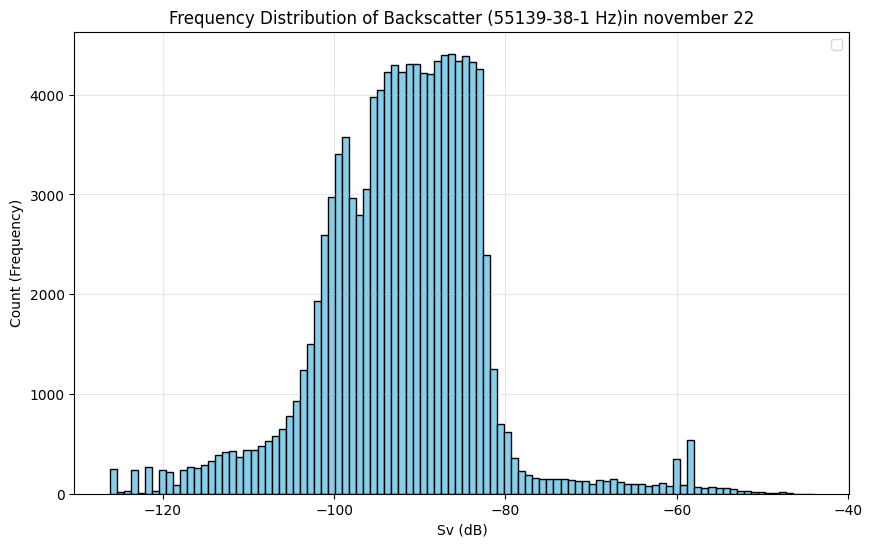

In [10]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# Load your monthly file
ds = xr.open_dataset('data_products_monthly/2307.nc') 

# Select one channel 

channel_freq = 38000  
if channel_freq not in ds.channel.values:
    channel_freq = ds.channel.values[0] # Fallback

data = ds.sel(channel=channel_freq)['Sv'].values.flatten()

# Remove NaNs so histogram doesn't crash
data_clean = data[~np.isnan(data)]

# Plot Histogram
plt.figure(figsize=(10, 6))
plt.hist(data_clean, bins=100, color='skyblue', edgecolor='black')

plt.title(f"Frequency Distribution of Backscatter ({channel_freq} Hz)in november 22")
plt.xlabel("Sv (dB)")
plt.ylabel("Count (Frequency)")
plt.grid(True, alpha=0.3)

plt.legend()
plt.show()

In [3]:
ds.name

AttributeError: 'Dataset' object has no attribute 'name'

## Why two missing line in monthly binned

Diagnosing 55139-125-3...

--- CHECK 1: Depth Coordinate Spacing ---
PASS: Depth grid is perfect (1m steps). No gaps in the grid itself.

Zooming in on ~25m:
[21. 22. 23. 24. 25. 26. 27.]

Zooming in on ~126m:
[121. 122. 123. 124. 125. 126. 127.]

--- CHECK 2: Counting NaNs per Depth ---
CONFIRMED: The following depths contain ONLY NaN values (100% empty):
[ 25.  97.  98.  99. 100. 101. 126.]


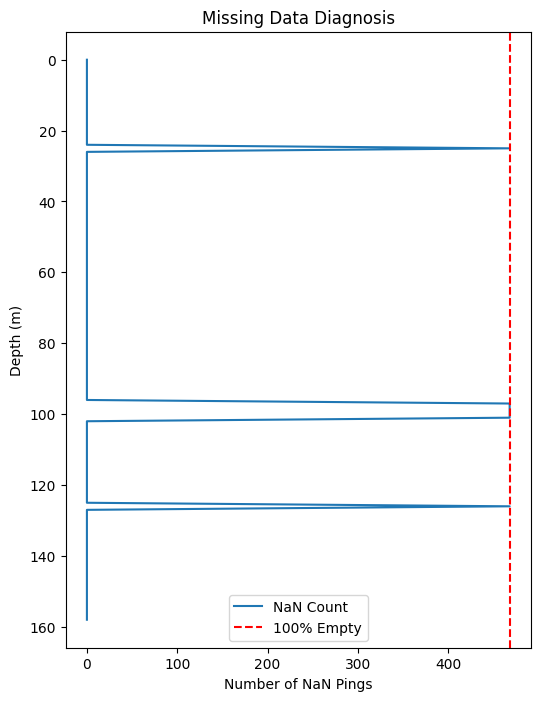

In [14]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

# Load the file
ds = xr.open_dataset('data_products_monthly/2211.nc') # Update filename

# Pick the channel with the lines 
test_channel = ds.channel.values[2] 
data = ds['Sv'].sel(channel=test_channel)

print(f"Diagnosing {test_channel}...")

# --- CHECK 1: GAP THEORY (Look at the Depth Coordinate) ---
print("\n--- CHECK 1: Depth Coordinate Spacing ---")
depths = ds.depth.values
diffs = np.diff(depths)

# Are all steps exactly 1.0?
if np.allclose(diffs, 1.0, atol=0.01):
    print("PASS: Depth grid is perfect (1m steps). No gaps in the grid itself.")
else:
    print("FAIL: Found irregular steps in depth grid!")
    # Find where the jump is not ~1.0
    bad_indices = np.where(~np.isclose(diffs, 1.0, atol=0.01))[0]
    for idx in bad_indices:
        print(f"  -> Jump at index {idx}: {depths[idx]:.2f}m to {depths[idx+1]:.2f}m (Gap: {diffs[idx]:.2f}m)")

# Look specifically at the suspicious areas (18m and 118m)
print("\nZooming in on ~25m:")
print(depths[(depths > 20) & (depths < 28)])

print("\nZooming in on ~126m:")
print(depths[(depths > 120) & (depths < 128)])


# --- CHECK 2: NaN THEORY (Are the values missing?) ---
print("\n--- CHECK 2: Counting NaNs per Depth ---")
# Count how many NaNs are in each depth row (across all time)
nan_counts = np.isnan(data).sum(dim='ping_time')
total_pings = data.sizes['ping_time']

# Find depths that are 100% NaN (All Empty)
empty_depths = ds.depth.where(nan_counts == total_pings, drop=True)

if len(empty_depths) > 0:
    print(f"CONFIRMED: The following depths contain ONLY NaN values (100% empty):")
    print(empty_depths.values)
else:
    print("No fully empty depths found.")

# --- PLOT THE DIAGNOSIS ---
plt.figure(figsize=(6, 8))
plt.plot(nan_counts, ds.depth, label='NaN Count')
plt.axvline(x=total_pings, color='r', linestyle='--', label='100% Empty')
plt.gca().invert_yaxis()
plt.title("Missing Data Diagnosis")
plt.xlabel("Number of NaN Pings")
plt.ylabel("Depth (m)")
plt.legend()
plt.show()


--- Select Monthly File ---
[0] 2211.nc
[1] 2212.nc
[2] 2212_range.nc
[3] 2301.nc
[4] 2302.nc
[5] 2303.nc
[6] 2304.nc
[7] 2304_with surface.nc
[8] 2305.nc
[9] 2306.nc
[10] 2307.nc
[11] 2308.nc

--- Select Channel for 2307.nc ---
[0] 55139-38-1
[1] 55139-67-2
[2] 55139-125-3
[3] 55139-200-4

Calculating Column Average (Converting to Linear domain first)...
Found dimension to average: depth


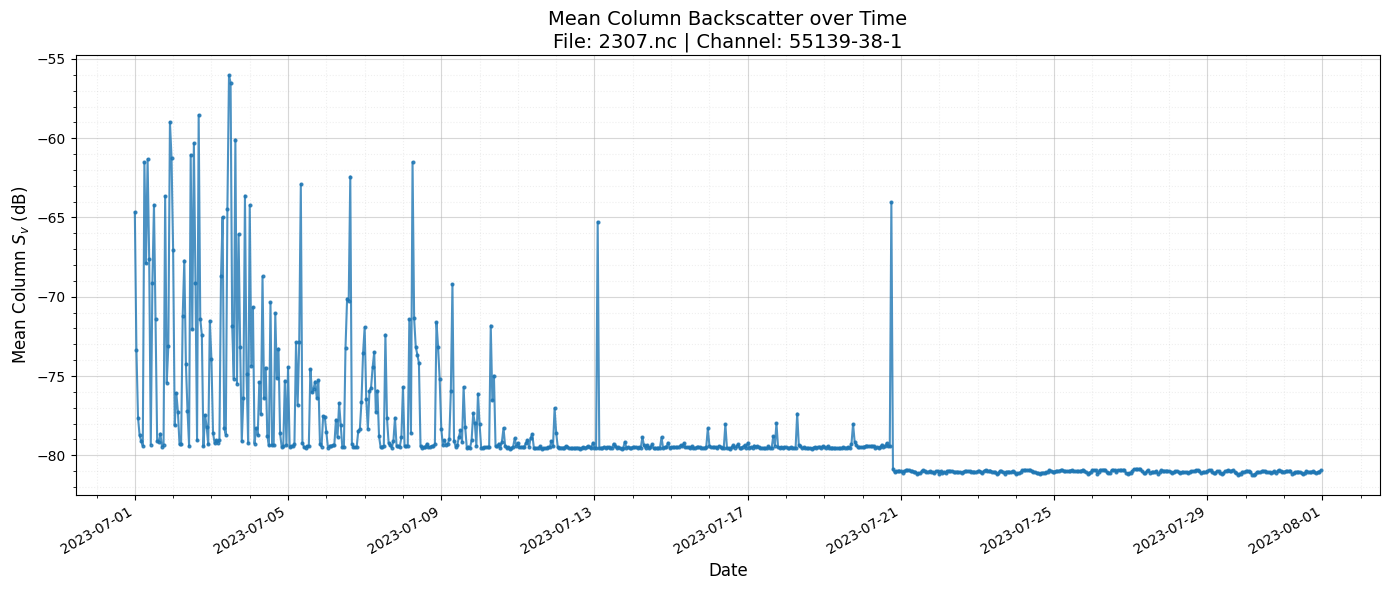


--- Summary Stats ---
Quietist Hour: -81.22 dB
Loudest Hour:  -56.03 dB


In [13]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# --- CONFIGURATION ---
input_folder = 'data_products_monthly'  # Where your monthly .nc files are saved
file_pattern = '*.nc'                   # Matches all NetCDF files

# 1. Select the File
search_path = os.path.join(input_folder, file_pattern)
files = sorted(glob.glob(search_path))

if not files:
    print(f"No files found in {input_folder}")
else:
    print("\n--- Select Monthly File ---")
    for i, f in enumerate(files):
        print(f"[{i}] {os.path.basename(f)}")
    
    file_idx = int(input("\nEnter number: ") or 0)
    target_file = files[file_idx]

    # 2. Open File and Select Channel
    ds = xr.open_dataset(target_file)
    chans = ds.channel.values
    
    print(f"\n--- Select Channel for {os.path.basename(target_file)} ---")
    for i, c in enumerate(chans):
        print(f"[{i}] {c}")
        
    chan_idx = int(input("\nEnter number: ") or 0)
    sel_chan = chans[chan_idx]

    # 3. Extract Data for the chosen channel
    da_sv = ds['Sv'].sel(channel=sel_chan)

    print("\nCalculating Column Average (Converting to Linear domain first)...")
    
    # --- THE MATH (Crucial Step) ---
    # 1. Convert dB (Sv) to Linear (sv)
    da_linear = 10 ** (da_sv / 10.0)
    
    # Identify which dimension to average over (depends on how you binned it)
    dim_to_avg = 'echo_range' if 'echo_range' in da_linear.dims else 'depth'
    print(f'Found dimension to average: {dim_to_avg}')
    # 2. Calculate the mean of the linear values across all depths for each hour
    # skipna=True ensures the NaN (empty) gaps don't ruin the math
    mean_linear = da_linear.mean(dim=dim_to_avg, skipna=True)
    
    # 3. Convert the linear average back to Decibels (dB)
    column_avg_Sv = 10 * np.log10(mean_linear)
    # -------------------------------

    # 4. PLOT THE LINE GRAPH
    plt.figure(figsize=(14, 6))
    
    # Plot Time vs. Averaged Sv
    plt.plot(
        column_avg_Sv.ping_time, 
        column_avg_Sv, 
        color='#1f77b4',       # Nice standard blue
        linewidth=1.5,
        marker='.',            # Puts a small dot at every 1-hour timestamp
        markersize=4,
        alpha=0.8
    )

    # Formatting
    plt.title(f"Mean Column Backscatter over Time\nFile: {os.path.basename(target_file)} | Channel: {sel_chan}", fontsize=14)
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Mean Column $S_v$ (dB)", fontsize=12)
    
    # Make the grid look professional
    plt.grid(True, which='major', linestyle='-', alpha=0.5)
    plt.grid(True, which='minor', linestyle=':', alpha=0.2)
    plt.minorticks_on()
    
    # Auto-format the dates on the X-axis so they don't overlap
    plt.gcf().autofmt_xdate()

    plt.tight_layout()
    plt.show()

    # Quick Stats Printout
    print("\n--- Summary Stats ---")
    print(f"Quietist Hour: {column_avg_Sv.min().values:.2f} dB")
    print(f"Loudest Hour:  {column_avg_Sv.max().values:.2f} dB")